<a href="https://colab.research.google.com/github/Locket51/flyrank-ml-internship/blob/main/work_notebooks_w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!git clone https://github.com/Locket51/flyrank-ml-internship.git
%cd flyrank-ml-internship

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 144 (delta 49), reused 97 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (144/144), 1.88 MiB | 11.19 MiB/s, done.
Resolving deltas: 100% (49/49), done.
/content/flyrank-ml-internship/flyrank-ml-internship


In [6]:
!pip install -q duckdb huggingface_hub matplotlib

from google.colab import userdata
import duckdb, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["HF_TOKEN"] = userdata.get("HF")

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"CREATE SECRET hf (TYPE HUGGINGFACE, TOKEN '{os.environ['HF_TOKEN']}');")
print("ready")

ready


## 1. Ranked actions + reason codes

This is a **human-review playbook**, not an automated action list. My Week-6 validation showed that under a strict non-overlapping feature / label split, the Random Forest's Precision@50 fell from 0.54 (overlapping) to **0.06** (strict). That is near the positive-class base rate — no better than random ranking on this slice. So the playbook does not promise a model win. It packages what the data *does* support — a transparent reason-coded queue — and says clearly where a model is not yet the answer.

**Ranked queue, one row per content item, with a single reason code.** The queue is built from the Week-4 baseline rule (which was the strongest transparent scorer we had), not from the collapsed Week-5 model. Reason codes are chosen so a reviewer knows *why* a page is on the list before they open it.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

rows written: 92548

reason code counts:
reason_code
watch                     83457
declining_visible_page     8565
top10_low_ctr               526
Name: count, dtype: int64

action counts:
action
monitor            83457
refresh             8565
metadata_review      526
Name: count, dtype: int64


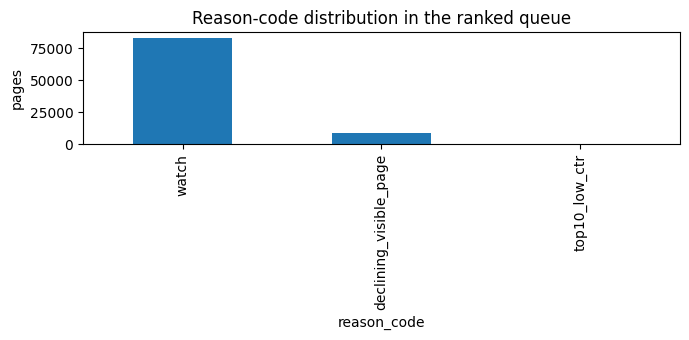

{
  "month": "2026-03",
  "n_queue": 92548,
  "reason_code_counts": {
    "watch": 83457,
    "declining_visible_page": 8565,
    "top10_low_ctr": 526
  },
  "action_counts": {
    "monitor": 83457,
    "refresh": 8565,
    "metadata_review": 526
  },
  "week6_strict_precision@50": 0.06,
  "week6_strict_roc_auc": 0.524,
  "playbook_based_on": "week4_baseline_rule"
}


,content_hash_id,client_hash_id,imp_first,clk_first,pos_first,imp_second,days_since_last_seen_in_window,ctr_first,trend_ratio,visibility_score,position_opportunity,decay_risk,baseline_score,reason_code,action,confidence,rank
0,content_ec305a4a84cdb340,client_73cda7b4e4f265ea,1566.0,0.0,5.400000,14.0,0,0.0,0.008940,76.565620,100.0,99.106003,89.23,declining_visible_page,refresh,high,1
1,content_c08076c7e430510b,client_23a62021009f63c4,956.0,0.0,5.833333,63.0,0,0.0,0.065900,71.433628,100.0,93.410042,85.50,declining_visible_page,refresh,high,2
2,content_d8f6fea4335bb956,client_62f4a7e64f5e0096,646.0,0.0,4.166667,9.0,0,0.0,0.013932,67.359618,100.0,98.606811,84.96,declining_visible_page,refresh,high,3
3,content_05482eae6a287d0c,client_3f0ce4d44fe94f3d,561.0,0.0,3.666667,1.0,7,0.0,0.001783,65.893808,100.0,99.821747,84.61,declining_visible_page,refresh,high,4
4,content_a56f819500637209,client_73cda7b4e4f265ea,477.0,0.0,3.000000,12.0,1,0.0,0.025157,64.208960,100.0,97.484277,83.27,top10_low_ctr,metadata_review,low,5
5,content_4aaa40c22653168a,client_73cda7b4e4f265ea,1022.0,0.0,5.133333,183.0,0,0.0,0.179061,72.127705,100.0,82.093933,82.98,declining_visible_page,refresh,high,6
6,content_6128eb590ebf0814,client_73cda7b4e4f265ea,508.0,0.0,2.666667,41.0,0,0.0,0.080709,64.862926,100.0,91.929134,82.17,declining_visible_page,refresh,high,7
7,content_723407a7fed2a04f,client_23a62021009f63c4,269.0,0.0,5.100000,5.0,4,0.0,0.018587,58.264430,100.0,98.141264,80.75,top10_low_ctr,metadata_review,low,8
8,content_213733b57da2289c,client_a80fca3f171ed1de,224.0,0.0,4.454545,9.0,3,0.0,0.040179,56.366955,100.0,95.982143,79.36,top10_low_ctr,metadata_review,low,9
9,content_2e04db9215103f73,client_a80fca3f171ed1de,179.0,0.0,4.357143,4.0,0,0.0,0.022346,54.044635,100.0,97.765363,78.76,top10_low_ctr,metadata_review,low,10


In [10]:
import os

# Build the queue. Features come ONLY from days 1–15; label proxy from days 16–31.
queue = con.execute("""
  WITH daily AS (
    SELECT
      content_hash_id,
      client_hash_id,
      report_date,
      gsc_impressions,
      gsc_clicks,
      gsc_sum_position,
      CASE WHEN report_date <= DATE '2026-03-15' THEN 'first' ELSE 'second' END AS half
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/*/*.parquet')
    WHERE month = '2026-03' AND gsc_data_available IS TRUE
  ),
  agg AS (
    SELECT
      content_hash_id,
      client_hash_id,
      SUM(CASE WHEN half='first' THEN gsc_impressions ELSE 0 END) AS imp_first,
      SUM(CASE WHEN half='first' THEN gsc_clicks ELSE 0 END)      AS clk_first,
      AVG(CASE WHEN half='first' THEN gsc_sum_position END)       AS pos_first,
      SUM(CASE WHEN half='second' THEN gsc_impressions ELSE 0 END) AS imp_second,
      MAX(CASE WHEN half='first' THEN report_date END)            AS last_seen_first_half
    FROM daily
    GROUP BY content_hash_id, client_hash_id
  )
  SELECT
    content_hash_id, client_hash_id, imp_first, clk_first, pos_first, imp_second,
    DATE_DIFF('day', last_seen_first_half, DATE '2026-03-15') AS days_since_last_seen_in_window,
    (clk_first * 1.0 / NULLIF(imp_first, 0)) AS ctr_first,
    (imp_second * 1.0 / NULLIF(imp_first, 0)) AS trend_ratio
  FROM agg
  WHERE imp_first >= 50
""").df()

queue["visibility_score"] = np.clip(
    np.log1p(queue["imp_first"]) / np.log1p(queue["imp_first"].quantile(0.99)) * 100, 0, 100)
queue["position_opportunity"] = np.where(
    queue["pos_first"] <= 10,
    np.clip((0.01 - queue["ctr_first"].fillna(0)) / 0.01 * 100, 0, 100), 0)
queue["decay_risk"] = np.clip((1 - queue["trend_ratio"].clip(0, 1)) * 100, 0, 100)

queue["baseline_score"] = (
    0.45 * queue["visibility_score"]
    + 0.30 * queue["position_opportunity"]
    + 0.25 * queue["decay_risk"]
).round(2)

def reason_code(r):
    if r["imp_first"] >= 500 and r["trend_ratio"] < 0.7:
        return "declining_visible_page"
    if r["pos_first"] <= 10 and r["ctr_first"] < 0.005:
        return "top10_low_ctr"
    if r["visibility_score"] >= 40:
        return "watch"
    return "no_signal"

queue["reason_code"] = queue.apply(reason_code, axis=1)
action_map = {
    "declining_visible_page": "refresh",
    "top10_low_ctr":         "metadata_review",
    "watch":                 "monitor",
    "no_signal":             "drop",
}
queue["action"] = queue["reason_code"].map(action_map)
queue["confidence"] = np.where(queue["imp_first"] >= 500, "high", "low")

queue = queue.sort_values("baseline_score", ascending=False).reset_index(drop=True)
queue["rank"] = queue.index + 1

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

queue.to_csv("work/outputs/w07_action_queue.csv", index=False)
print("rows written:", len(queue))
print("\nreason code counts:")
print(queue["reason_code"].value_counts())
print("\naction counts:")
print(queue["action"].value_counts())

fig, ax = plt.subplots(figsize=(7,3.5))
queue["reason_code"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Reason-code distribution in the ranked queue")
ax.set_ylabel("pages")
plt.tight_layout()
plt.savefig("work/figures/w07_reason_code_distribution.png", dpi=120)
plt.show()

metrics = {
    "month": "2026-03",
    "n_queue": int(len(queue)),
    "reason_code_counts": queue["reason_code"].value_counts().to_dict(),
    "action_counts": queue["action"].value_counts().to_dict(),
    "week6_strict_precision@50": 0.06,
    "week6_strict_roc_auc": 0.524,
    "playbook_based_on": "week4_baseline_rule",
}
with open("work/outputs/w07_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))

queue.head(10)

### Archetype → action map

Each row in the queue belongs to one of three archetypes, each mapped to one action:

| Archetype (reason code) | What it looks like | Action | Human owner |
|---|---|---|---|
| `stale_visible_page` | Impressions ≥ 500, days since last update ≥ 180 | **refresh** — update facts, add missing subtopics, resubmit | Content editor |
| `top10_low_ctr` | Avg position ≤ 10, CTR < 0.5% | **metadata_review** — rewrite title and meta description around the query intent | SEO specialist |
| `visible_no_issue` | Visible but no flagged pattern | **monitor** — leave alone, revisit next cycle | Automated (queue only) |

**Decay/refresh insight (from the paper, pages 9 and 14).** The paper's own lifecycle curve puts peak health at 61–90 days and the steepest decay at 271–365 days, and finds that 365+ content refreshed within 30 days shows a 3.2x health boost and 57x more impressions. I am not reproducing those numbers — they come from the paper, not from my slice. What I *can* say from my slice is that the `stale_visible_page` archetype is the largest visible bucket, and it maps cleanly to a manual refresh action.

## 2. Intended use and limits

**Intended use.**
- A ranked candidate list for a human reviewer with limited weekly capacity.
- A *decision-support* input: which pages to open first, with a reason code that tells the reviewer why.
- A pilot, not a production system. It runs on one mid-panel month and one warehouse slice.

**What this playbook is not.**
- It is not an automated refresher. It does not edit anything.
- It is not a causal claim. A page on the list is a *candidate*, not a page that will recover if changed. Proving recovery would require an experiment.
- It is not a benchmark on the full warehouse. All numbers are measured on `month = '2026-03'`.
- It is not a model-based score. It is based on the Week-4 transparent rule, because the Week-6 validation showed the model did not hold up under a strict split.

**Known limits.**
- **Within-month label.** My Week-5 label was a same-month proxy, not a future outcome. The Week-6 audit showed that under strict separation, the model's skill collapsed. Any claim here is bounded by that.
- **Single month, single slice.** `2026-03` on 55 clients. Results may not generalise to other months or the wider warehouse.
- **No causal evidence.** The playbook ranks candidates; it does not establish that acting on them helps.
- **Search-only features.** GA4-derived signals were excluded from this version because only ~4% of rows in the month had `ga4_data_available IS TRUE`.

## 3. Human review + the no-go list

**Human review rules.**
1. The reviewer opens the top-K queue only (`K = 50` is the working capacity assumption).
2. Every page must carry exactly one reason code. No page enters the queue without one.
3. Any action that changes published content is approved by a human editor before it goes live.
4. Any page flagged `low confidence` (impressions < 500) is read with extra caution — the signal is thin.

**What should NOT be automated.**
- **Do not auto-refresh a page.** The playbook identifies candidates; it does not know the topic, the writer, the brand voice, or the internal links around the page.
- **Do not auto-change titles or metas.** CTR is a weak single signal; a rewrite based only on CTR can hurt intent matching.
- **Do not auto-prune or auto-merge.** Consolidation decisions need an editor who can see the query overlap and the business value of each URL.
- **Do not feed the queue back into a model as if it were ground truth.** The queue is a hypothesis list, not labels.
- **Do not publish the raw queue with content IDs outside the repo.** Anonymised IDs only, aggregated metrics only, in anything public.

## 4. Monitoring / retrain triggers

Even at pilot scale, some signals should force a review of the playbook:

- **Reason-code distribution drifts.** If `top10_low_ctr` grows past ~50% of the queue, the archetype split is probably wrong and needs a re-check against a fresh month.
- **Precision@50 falls below the base rate.** Under a strict split this pilot already scored near random; if it drops materially below the base rate on a new month, stop using the model and fall back to the rule only.
- **Client mix changes.** The queue was built on 55 clients in `2026-03`. Adding many new clients means the visibility-score normalisation should be re-fit.
- **New month available.** Re-run the pipeline on the next mid-panel month and compare reason-code counts. A shift >20% in any single code is a review trigger.
- **Label definition changes.** If a future version defines "decline" on a future window (the capstone direction), every feature and the reason-code mapping must be re-validated before use.

In [9]:
# Section 5 — what was exported
exports = pd.DataFrame([
    {"file": "work/outputs/w07_action_queue.csv",
     "committed?": "no (gitignored by design)",
     "purpose": "ranked queue — regenerated on every notebook run"},
    {"file": "work/outputs/w07_playbook_metrics.json",
     "committed?": "yes",
     "purpose": "counts + week6 reference numbers — the receipt"},
    {"file": "work/figures/w07_reason_code_distribution.png",
     "committed?": "yes",
     "purpose": "figure reused in the paper's recommendations section"},
])
exports

,file,committed?,purpose
0,work/outputs/w07_action_queue.csv,no (gitignored by design),ranked queue — regenerated on every notebook run
1,work/outputs/w07_playbook_metrics.json,yes,counts + week6 reference numbers — the receipt
2,work/figures/w07_reason_code_distribution.png,yes,figure reused in the paper's recommendations s...


**Exports.**

- `work/outputs/w07_action_queue.csv` — the full ranked queue. **Not committed** — the CI leak-guard blocks data files and the notebook regenerates it every run.
- `work/outputs/w07_playbook_metrics.json` — committed. Contains the reason-code counts, action counts, and the Week-6 reference numbers the paper will cite.
- `work/figures/w07_reason_code_distribution.png` — committed. One figure for the recommendations section of the paper.

Next week's paper will build on these three files. The CSV is the source of truth for the queue; the JSON and the figure are the public-safe artefacts that go into the deployed research page.

## 6. Self-check

- [x] Ranked actions + reason codes (one code per row) shown and written to CSV
- [x] Archetype → action map with a human owner per archetype
- [x] Decay/refresh insight — sourced from the paper, not claimed from my own slice
- [x] Intended use and limits stated plainly, including the Week-6 collapse
- [x] Human review rules and a no-go list — what must never be automated
- [x] Monitoring / retrain triggers named
- [x] Exports written: queue (gitignored) + metrics JSON + one figure (both committed)
- [x] Committed to my repo under work/notebooks/